In [1]:
import numpy as np
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt


# -----------------------------------------------------------------
# 1. DESCARGA Y CARGA DEL DATASET
# -----------------------------------------------------------------
# tf.keras.datasets.fashion_mnist.load_data()
# Descarga el dataset Fashion MNIST desde los servidores de Keras y lo entrega
# ya separado en conjunto de entrenamiento y de prueba.
# Devuelve dos tuplas: (x_train, y_train) y (x_test, y_test)
#   x_train: 60.000 imagenes de 28x28 pixeles (escala de grises, 0-255)
#   y_train: 60.000 rotulos (numeros de 0 a 9, uno por clase de prenda)
#   x_test / y_test: 10.000 imagenes/rotulos para evaluar la red
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Forma x_train:", x_train.shape)   # (60000, 28, 28)
print("Forma y_train:", y_train.shape)   # (60000,)
print("Forma x_test :", x_test.shape)    # (10000, 28, 28)

Forma x_train: (60000, 28, 28)
Forma y_train: (60000,)
Forma x_test : (10000, 28, 28)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 - 5s - 6ms/step - accuracy: 0.6443 - loss: 1.0342 - val_accuracy: 0.7538 - val_loss: 0.6534
Epoch 2/10
844/844 - 4s - 4ms/step - accuracy: 0.7724 - loss: 0.6152 - val_accuracy: 0.7947 - val_loss: 0.5740
Epoch 3/10
844/844 - 6s - 7ms/step - accuracy: 0.8005 - loss: 0.5548 - val_accuracy: 0.8070 - val_loss: 0.5301
Epoch 4/10
844/844 - 4s - 4ms/step - accuracy: 0.8154 - loss: 0.5194 - val_accuracy: 0.8182 - val_loss: 0.5115
Epoch 5/10
844/844 - 4s - 4ms/step - accuracy: 0.8255 - loss: 0.4919 - val_accuracy: 0.8283 - val_loss: 0.4779
Epoch 6/10
844/844 - 5s - 6ms/step - accuracy: 0.8333 - loss: 0.4706 - val_accuracy: 0.8352 - val_loss: 0.4678
Epoch 7/10
844/844 - 4s - 4ms/step - accuracy: 0.8395 - loss: 0.4540 - val_accuracy: 0.8382 - val_loss: 0.4425
Epoch 8/10
844/844 - 4s - 4ms/step - accuracy: 0.8448 - loss: 0.4383 - val_accuracy: 0.8410 - val_loss: 0.4364
Epoch 9/10
844/844 - 6s - 7ms/step - accuracy: 0.8495 - loss: 0.4252 - val_accuracy: 0.8442 - val_loss: 0.4236
E

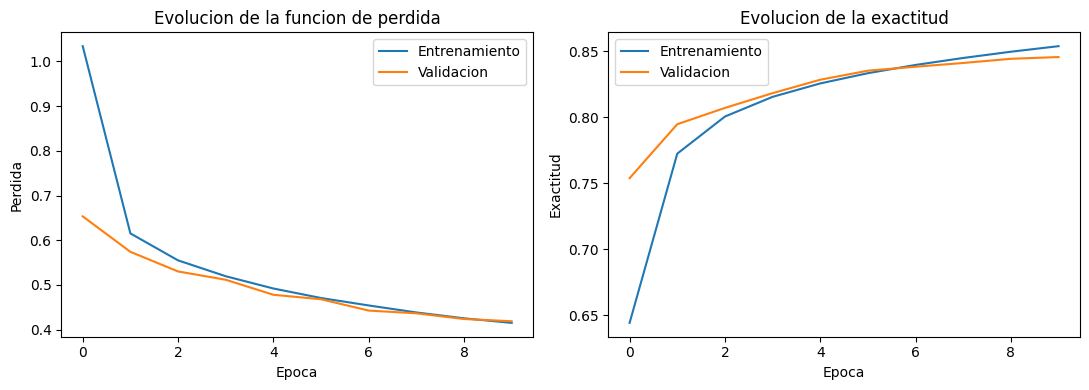

<Figure size 640x480 with 0 Axes>

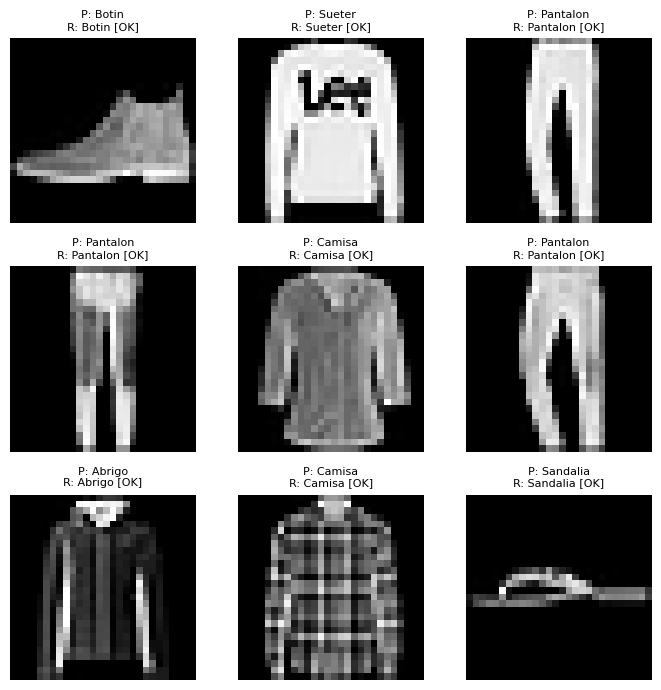


CONCLUSIONES
- Exactitud final en entrenamiento: 85.37 %
- Exactitud final en validacion:    84.55 %
- Exactitud en el conjunto de prueba: 83.87 %
- La exactitud de entrenamiento y validacion son similares, lo que indica que la red esta generalizando adecuadamente y no presenta un sobre-entrenamiento marcado.
- El modelo usa una red feed-forward totalmente conectada (sin convoluciones), por lo que no aprovecha la estructura espacial de la imagen; una CNN normalmente obtendria una exactitud mayor en este mismo problema.
- El proceso completo (propagacion, calculo del error, backpropagation y actualizacion de pesos) es exactamente el mismo algoritmo explicado en el documento, solo que TensorFlow lo ejecuta de forma automatica y optimizada dentro de model.fit().


<Figure size 640x480 with 0 Axes>

In [3]:
# Fashion MNIST tiene 10 categorias de prendas, numeradas de 0 a 9.
# Esta lista muestra el nombre en lugar del numero.
clases = ["Camiseta/top", "Pantalon", "Sueter", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botin"]


# -----------------------------------------------------------------
# 2. PREPROCESAMIENTO
# -----------------------------------------------------------------
# Los pixeles vienen en el rango [0, 255]. Los dividimos entre 255.0
# para normalizarlos al rango [0, 1]. Esto es equivalente al vector
# de "caracteristicas" (features) X del documento, pero aqui cada
# imagen aporta 784 caracteristicas (28 x 28 pixeles).
# Normalizar ayuda a que la red converja mas rapido y de forma mas
# estable (evita que la funcion de activacion sigmoide/ReLU trabaje
# con valores muy grandes).
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# -----------------------------------------------------------------
# 3. DEFINICION DE LA RED NEURONAL (topologia)
# -----------------------------------------------------------------
# tf.keras.Sequential crea una red "feedforward" (como las vistas en
# el documento): los datos fluyen de una capa a la siguiente, sin
# retroalimentacion.
#
#   Input(shape=(28,28))  -> capa de entrada, cada imagen es una
#                             matriz de 28x28 (no un vector todavia)
#   Flatten()              -> convierte la matriz 28x28 en un vector
#                             de 784 valores (el vector X de entrada
#                             de una neurona artificial, ver 5.2.2)
#   Dense(128, relu)       -> primera capa oculta (capa 1), 128
#                             neuronas, cada una calcula
#                             Z = W.X + b y aplica la funcion de
#                             activacion ReLU (figura 5.7 del doc.)
#   Dense(64, relu)        -> segunda capa oculta (capa 2), 64
#                             neuronas, misma logica que la anterior
#   Dense(10, softmax)     -> capa de salida con 10 neuronas (una por
#                             clase de prenda). softmax convierte las
#                             salidas en probabilidades que suman 1,
#                             es la generalizacion multi-clase de la
#                             funcion sigmoide vista en 5.2.2
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

# model.summary() imprime la topologia de la red: cada capa, su forma
# de salida y el numero de parametros (pesos W y sesgos b) que debe
# aprender. Es el equivalente a las "matrices de pesos" W1, W2, W3
# del documento, pero calculadas automaticamente segun el tamano de
# cada capa.
model.summary()


# -----------------------------------------------------------------
# 4. COMPILACION DEL MODELO
# -----------------------------------------------------------------
# model.compile() define como se va a entrenar la red:
#   optimizer="adam"   -> algoritmo de descenso de gradiente que
#                          ademas ajusta automaticamente la tasa de
#                          aprendizaje (eta en el documento) durante
#                          el entrenamiento. Es una version mejorada
#                          del descenso de gradiente simple visto en
#                          la seccion de Backpropagation.
#   loss="sparse_categorical_crossentropy"
#                       -> funcion de perdida para clasificacion
#                          multi-clase cuando los rotulos son
#                          numeros enteros (0 a 9) y no vectores
#                          one-hot. Es analoga a la funcion de
#                          perdida E = 1/2 (e)^2 del documento, pero
#                          adaptada a probabilidades (softmax).
#   metrics=["accuracy"] -> ademas de la perdida, se reporta el
#                          porcentaje de aciertos en cada epoca.
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])


# -----------------------------------------------------------------
# 5. ENTRENAMIENTO
# -----------------------------------------------------------------
# model.fit() ejecuta el proceso de aprendizaje supervisado: por cada
# epoca, TensorFlow propaga las imagenes hacia adelante, calcula el
# error contra los rotulos verdaderos y aplica Backpropagation para
# ajustar todos los pesos W y sesgos b de la red (el mismo algoritmo
# explicado en la seccion 5.5 del documento, pero implementado de
# forma optimizada internamente).
#   epochs=10          -> numero de veces que la red ve todo el
#                          conjunto de entrenamiento completo
#   batch_size=64       -> en vez de actualizar los pesos ejemplo por
#                          ejemplo, se agrupan 64 imagenes y se
#                          actualiza el promedio del error de ese
#                          grupo (mas rapido y estable)
#   validation_split=0.1 -> aparta el 10% del entrenamiento como
#                          conjunto de validacion, para revisar que
#                          la red generaliza y no solo memoriza
#                          (ver "Generalizacion del aprendizaje",
#                          seccion 5.4 del documento)
historial = model.fit(x_train, y_train,
                       epochs=10,
                       batch_size=64,
                       validation_split=0.1,
                       verbose=2)


# -----------------------------------------------------------------
# 6. EVALUACION SOBRE EL CONJUNTO DE PRUEBA
# -----------------------------------------------------------------
# model.evaluate() propaga el conjunto de prueba (que la red nunca
# vio durante el entrenamiento) y devuelve la perdida final y la
# exactitud (accuracy) real del modelo. Este es el "conjunto de
# prueba" que menciona el documento para estimar el comportamiento
# de la red en el mundo real.
perdida_test, exactitud_test = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPerdida en el conjunto de prueba:   {perdida_test:.4f}")
print(f"Exactitud en el conjunto de prueba: {exactitud_test:.4f}  "
      f"({exactitud_test*100:.2f} %)")


# -----------------------------------------------------------------
# 7. PREDICCIONES DE EJEMPLO
# -----------------------------------------------------------------
# model.predict() propaga nuevas imagenes a traves de la red ya
# entrenada y devuelve, para cada una, el vector de 10 probabilidades
# (una por clase). np.argmax() selecciona la clase con mayor
# probabilidad, es decir, la prediccion final de la red.
probs = model.predict(x_test[:9], verbose=0)
predicciones = np.argmax(probs, axis=1)

print("\nEjemplos de prediccion (Prediccion vs Real):")
for i in range(9):
    print(f"  {clases[predicciones[i]]:<15} vs  {clases[y_test[i]]}")


# -----------------------------------------------------------------
# 8. GRAFICAS
# -----------------------------------------------------------------
# Se grafican la perdida y la exactitud del entrenamiento y de la
# validacion en cada epoca. Esto permite observar visualmente si la
# red esta en underfitting, en un ajuste adecuado, o en overfitting
# (ver figura 5.12 del documento).
# -----------------------------------------------------------------
# 8. GRAFICAS
# -----------------------------------------------------------------

# Curvas de entrenamiento
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(historial.history["loss"], label="Entrenamiento")
axs[0].plot(historial.history["val_loss"], label="Validacion")
axs[0].set_title("Evolucion de la funcion de perdida")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Perdida")
axs[0].legend()

axs[1].plot(historial.history["accuracy"], label="Entrenamiento")
axs[1].plot(historial.history["val_accuracy"], label="Validacion")
axs[1].set_title("Evolucion de la exactitud")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Exactitud")
axs[1].legend()

plt.tight_layout()

# Mostrar en pantalla
plt.show()

# Guardar opcionalmente
plt.savefig("curvas_entrenamiento.png")

# ---------------------------------------------------------
# Ejemplos de prediccion
# ---------------------------------------------------------

fig2, axs2 = plt.subplots(3, 3, figsize=(7, 7))

for i, ax in enumerate(axs2.flat):
    ax.imshow(x_test[i], cmap="gray")

    correcto = "OK" if predicciones[i] == y_test[i] else "X"

    ax.set_title(
        f"P: {clases[predicciones[i]]}\n"
        f"R: {clases[y_test[i]]} [{correcto}]",
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()

# Mostrar en pantalla
plt.show()

# Guardar opcionalmente
plt.savefig("ejemplos_prediccion.png")


# -----------------------------------------------------------------
# 9. CONCLUSIONES (generadas a partir de los resultados obtenidos)
# -----------------------------------------------------------------
acc_train_final = historial.history["accuracy"][-1]
acc_val_final = historial.history["val_accuracy"][-1]
brecha = acc_train_final - acc_val_final

print("\n" + "=" * 60)
print("CONCLUSIONES")
print("=" * 60)
print(f"- Exactitud final en entrenamiento: {acc_train_final*100:.2f} %")
print(f"- Exactitud final en validacion:    {acc_val_final*100:.2f} %")
print(f"- Exactitud en el conjunto de prueba: {exactitud_test*100:.2f} %")

if brecha > 0.05:
    print("- La exactitud de entrenamiento es notablemente mayor que la de "
          "validacion, lo que sugiere un principio de sobre-entrenamiento "
          "(overfitting): la red esta memorizando detalles del conjunto "
          "de entrenamiento en vez de generalizar. Se recomendaria reducir "
          "el numero de epocas, agregar regularizacion (Dropout) o "
          "aumentar los datos de entrenamiento.")
else:
    print("- La exactitud de entrenamiento y validacion son similares, lo "
          "que indica que la red esta generalizando adecuadamente y no "
          "presenta un sobre-entrenamiento marcado.")